In [ ]:
import numpy as np
import pandas as pd


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from xgboost import plot_importance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.tree import plot_tree

In [ ]:
import pickle
df0 = pd.read_csv("/content/HR_comma_sep.csv")
df0.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


Gather basic information about the data.

In [ ]:
df0.describe(include='all')

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999,14999
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sales,low
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4140,7316
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268,NaN,NaN
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281,NaN,NaN
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000,NaN,NaN


Gather descriptive statistics about the data.

In [ ]:
df0 = df0.rename(columns={'Work_accident': 'work_accident',
                          'average_montly_hours': 'average_monthly_hours',
                          'time_spend_company': 'tenure',
                          'Department': 'department'})
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

As a data cleaning step, the columns were renamed and standardized so that they are all concise, correctly spelled and in snake_case

In [ ]:
df0.isna().sum()

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_monthly_hours,0
tenure,0
work_accident,0
left,0
promotion_last_5years,0
department,0
salary,0


Check for missing values in the dataset

In [ ]:
df0.duplicated().sum()

3008

There are 3,008 rows that contain duplicates, which is about 20% of the data. Inspect some of the rows containing duplicates.

In [ ]:
df0[df0.duplicated()].head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low


With 10 columns and several continuous variables among them, it is likely that these observations are invalid so they will be dropped.

In [ ]:
df1 = df0.drop_duplicates(keep='first')
df1.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


Check for outliers in the data.

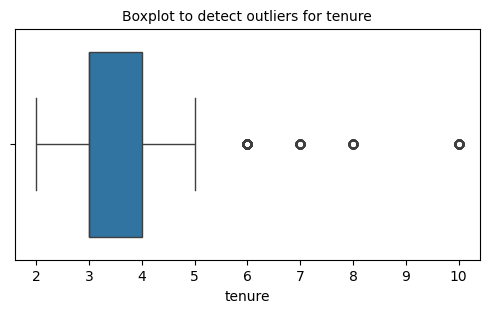

In [ ]:
plt.figure(figsize=(6,3))
plt.title('Boxplot to detect outliers for tenure', fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
sns.boxplot(x=df1['tenure'])
plt.show()

The diagram shows that there are outliers in the tenure variable. Next, we will investigate the outliers in this particular column.

In [ ]:
percentile25 = df1['tenure'].quantile(0.25)
percentile75 = df1['tenure'].quantile(0.75)
iqr = percentile75 - percentile25

upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr
print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

outliers = df1[(df1['tenure'] > upper_limit) | (df1['tenure'] < lower_limit)]

print("Number of rows in the data with outliers in `tenure`:", len(outliers))

Lower limit: 1.5
Upper limit: 5.5
Number of rows in the data with outliers in `tenure`: 824


Some model types are susceptible to outliers. When we get to the stage of constructing the model, we will consider whether to remove or keep these outliers based on the type of model we decide to use.

In [ ]:
print(df1['left'].value_counts())
print()

print('Percentages:')
print((df1['left'].value_counts(normalize=True))*100)

left
0    10000
1     1991
Name: count, dtype: int64

Percentages:
left
0    83.39588
1    16.60412
Name: proportion, dtype: float64


There is an imbalance in the classes but the majority class does not go beyond 90%. Since the imbalance is not extreme, we will continue without modifying the class balance.

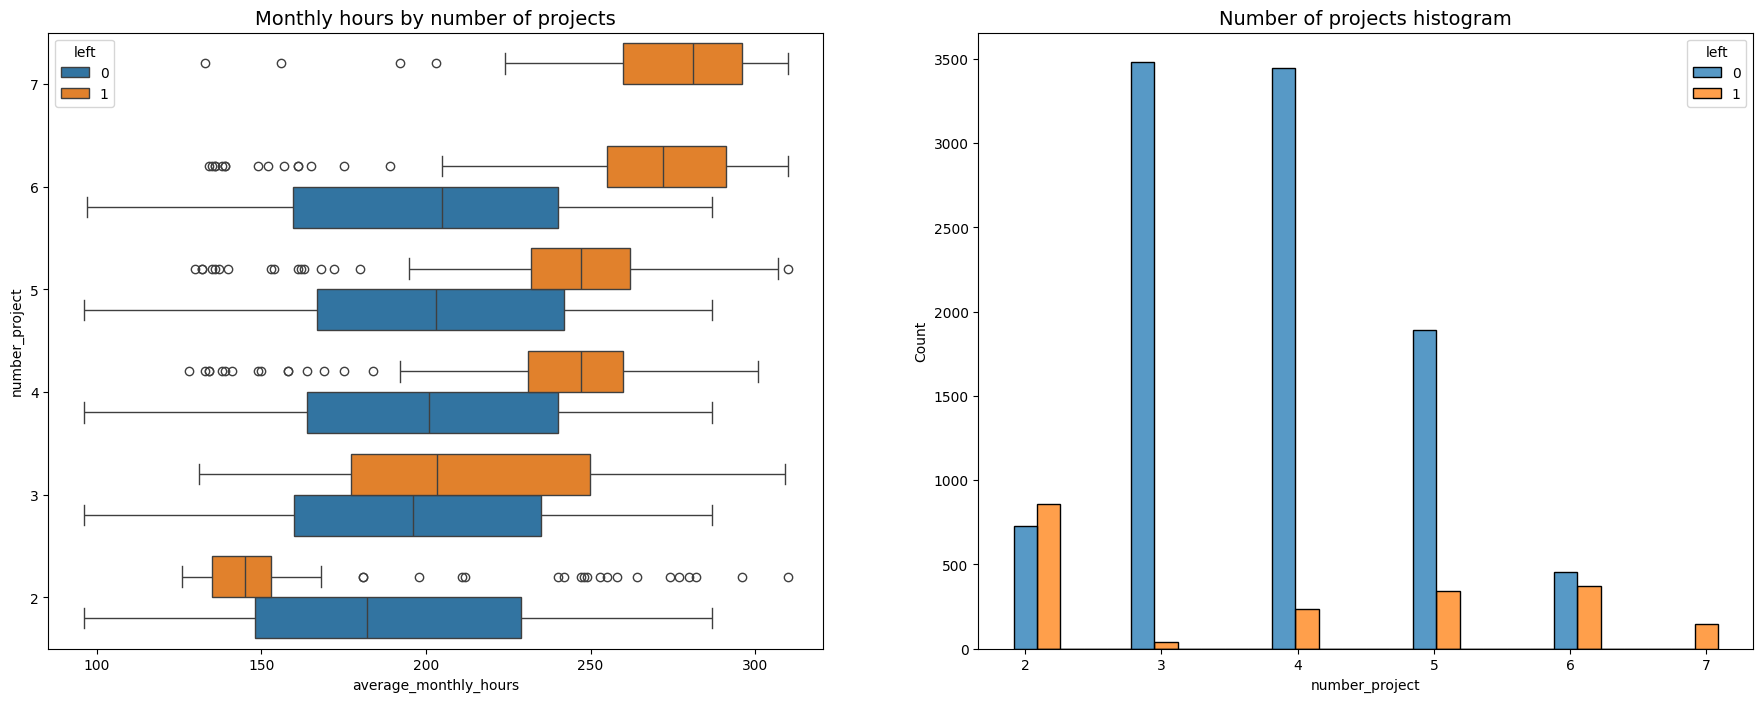

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(1, 2, figsize = (22,8))

sns.boxplot(data=df1, x='average_monthly_hours', y='number_project', hue='left', orient="h", ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Monthly hours by number of projects', fontsize='14')

tenure_stay = df1[df1['left']==0]['number_project']
tenure_left = df1[df1['left']==1]['number_project']
sns.histplot(data=df1, x='number_project', hue='left', multiple='dodge', shrink=2, ax=ax[1])
ax[1].set_title('Number of projects histogram', fontsize='14')

plt.show()


Two groups of employees left the company: (A) those with fewer hours, possibly fired or leaving soon, and (B) those working much more hours, likely quitting voluntarily. All employees with seven projects left, and those with six worked 255–295 hours per week. The ideal number of projects seems to be 3–4, as these groups had the lowest departure rates. Employees worked an average of 166.7 hours per month, which is much higher than expected, indicating overwork. Those who worked on more projects had a bigger increase in hours, especially among those who left. We need to confirm that all employees with seven projects left.

In [ ]:
df1[df1['number_project']==7]['left'].value_counts()

,count
left,
1,145


Text(0.5, 1.0, 'Monthly hours by last evaluation score')

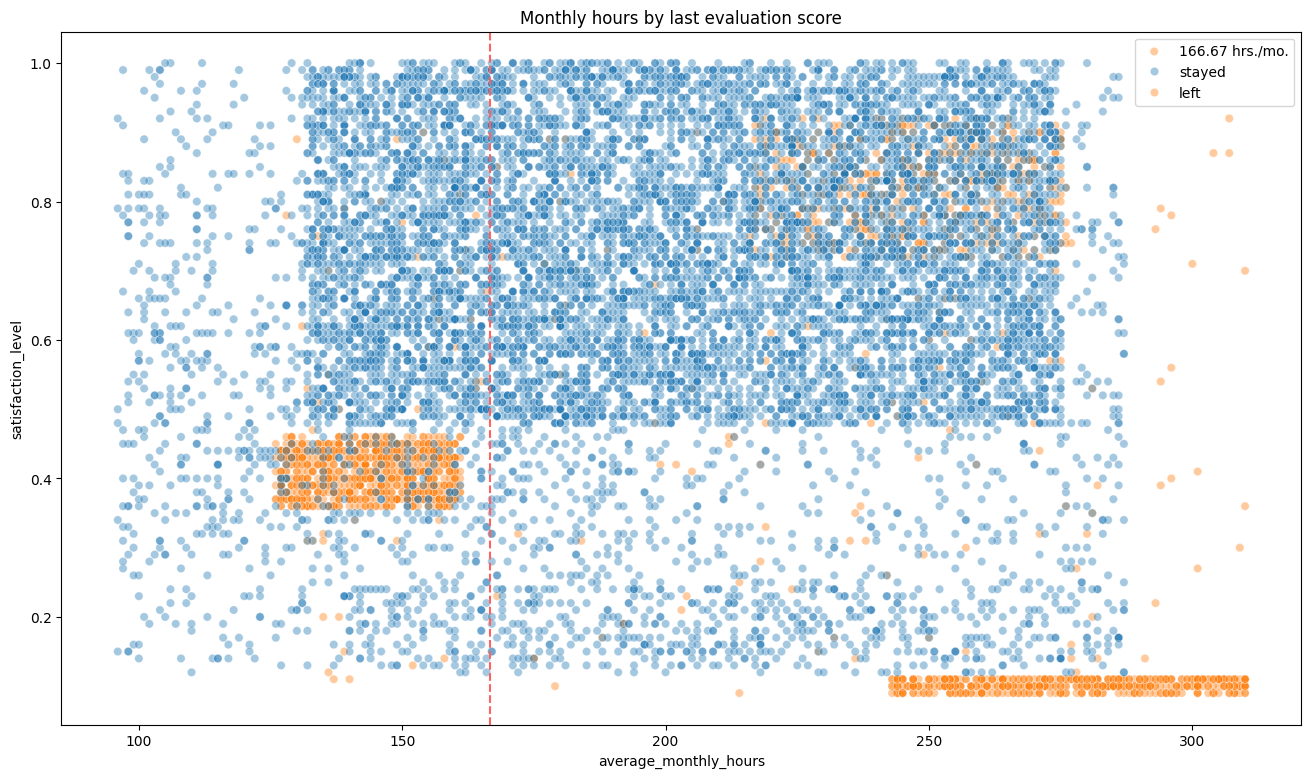

In [ ]:
plt.figure(figsize=(16, 9))
sns.scatterplot(data=df1, x='average_monthly_hours', y='satisfaction_level', hue='left', alpha=0.4)
plt.axvline(x=166.7, color='#ff6361', label='166.7 hrs./mo.', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'stayed', 'left'])
plt.title('Monthly hours by last evaluation score', fontsize='12')


The diagram shows three groups of employees: one working very long hours (240–315 hours/month) with low satisfaction, another with more typical hours but still low satisfaction, and a third with moderate hours and higher satisfaction. The odd shape of the data suggests potential manipulation or synthetic data. Future visualizations could explore satisfaction and tenure.

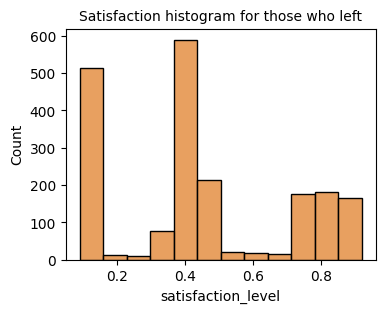

In [ ]:
plt.figure(figsize=(4,3))
# Create histogram showing distribution of `satisfaction_level`
tenure_left = df1[df1['left']==1]['satisfaction_level']
sns.histplot(data=tenure_left, color ='#e1812b')
plt.title('Satisfaction histogram for those who left', fontsize='10')

plt.show()

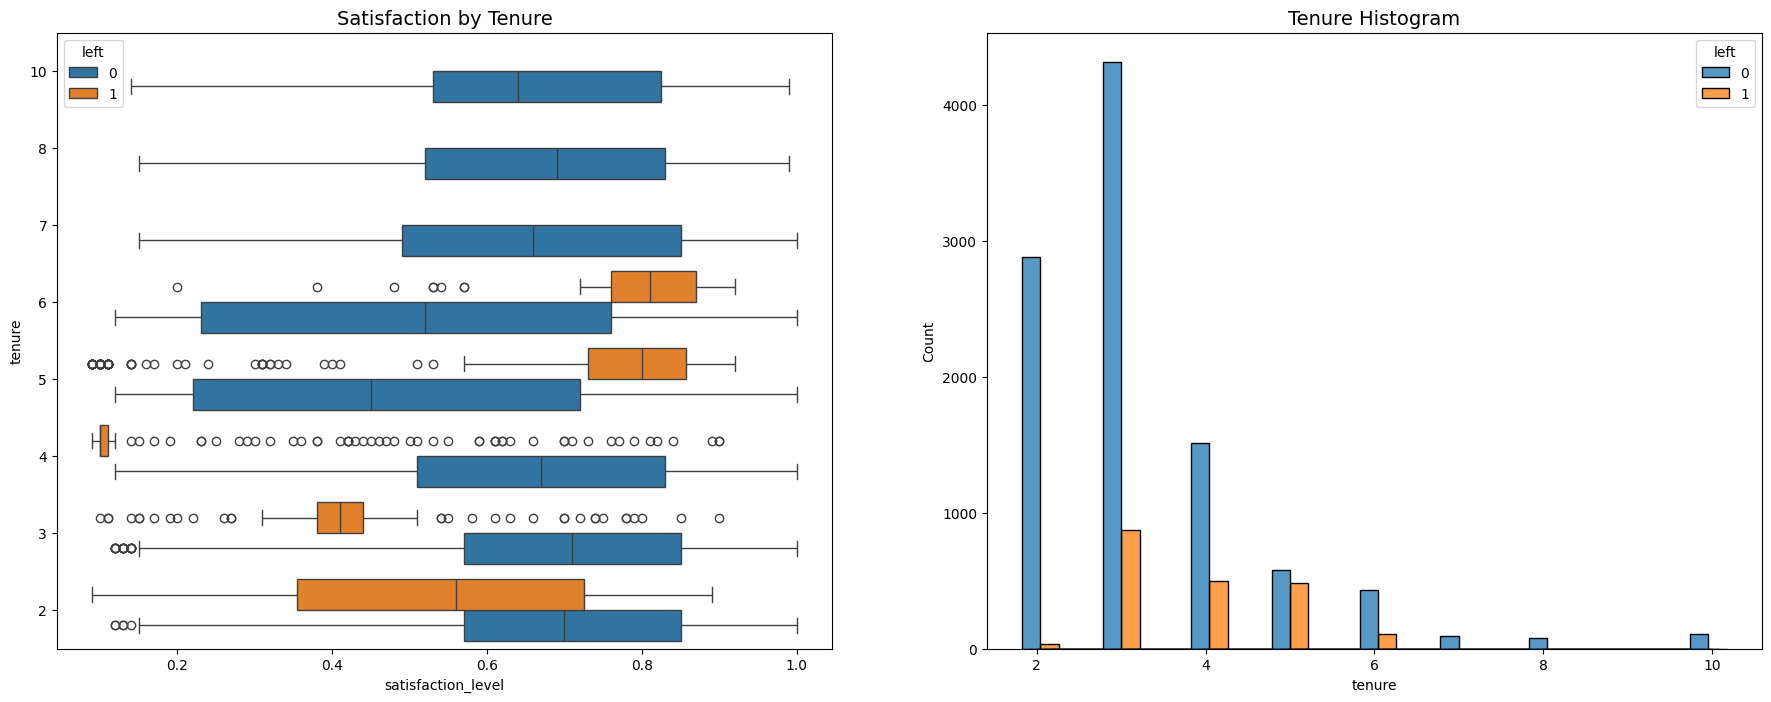

In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (22,8))

# Create boxplot showing distributions of `satisfaction_level` by tenure, comparing employees who stayed versus those who left
sns.boxplot(data=df1, x='satisfaction_level', y='tenure', hue='left', orient="h", ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Satisfaction by Tenure', fontsize='14')

# Create histogram showing distribution of `tenure`, comparing employees who stayed versus those who left
tenure_stay = df1[df1['left']==0]['tenure']
tenure_left = df1[df1['left']==1]['tenure']
sns.histplot(data=df1, x='tenure', hue='left', multiple='dodge', shrink=5, ax=ax[1])
ax[1].set_title('Tenure Histogram', fontsize='14')

plt.show()

In [ ]:
df1.groupby(['left'])['satisfaction_level'].agg(['mean','median'])

,mean,median
left,,
0,0.667365,0.69
1,0.440271,0.41


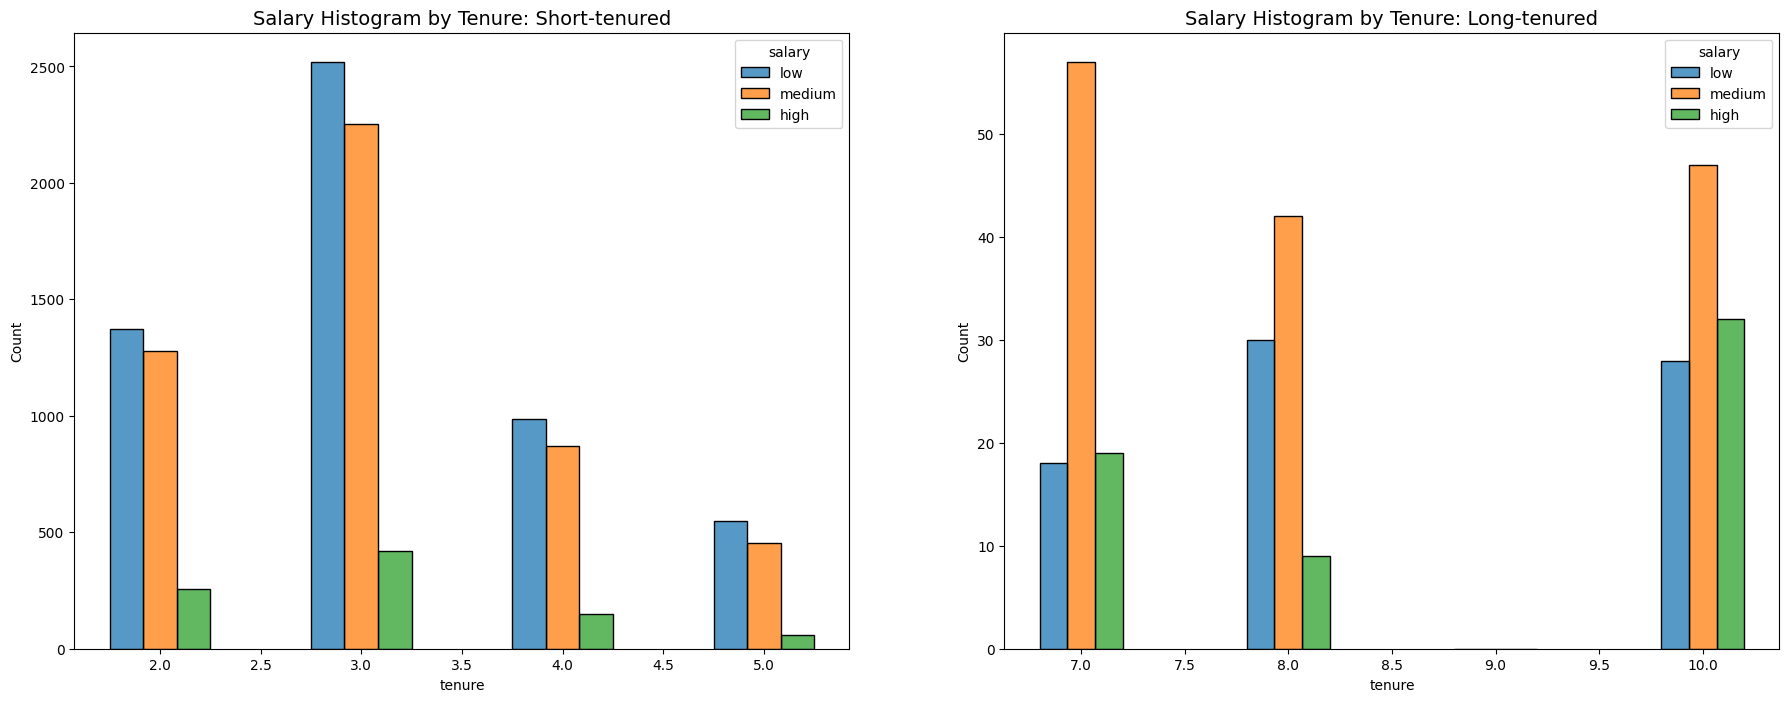

In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (22,8))

# Define short-tenured employees
tenure_short = df1[df1['tenure']<6]

# Define long-tenured employees
tenure_long = df1[df1['tenure']>6]

# Plot short-tenured histogram
sns.histplot(data=tenure_short, x='tenure', hue='salary', discrete=1,
             hue_order=['low', 'medium', 'high'], multiple='dodge', shrink=.5, ax=ax[0])
ax[0].set_title('Salary Histogram by Tenure: Short-tenured', fontsize='14')

# Plot long-tenured histogram
sns.histplot(data=tenure_long, x='tenure', hue='salary', discrete=1,
             hue_order=['low', 'medium', 'high'], multiple='dodge', shrink=.4, ax=ax[1])
ax[1].set_title('Salary Histogram by Tenure: Long-tenured', fontsize='14');

Text(0.5, 1.0, 'Monthly Hours by Last Evaluation Score')

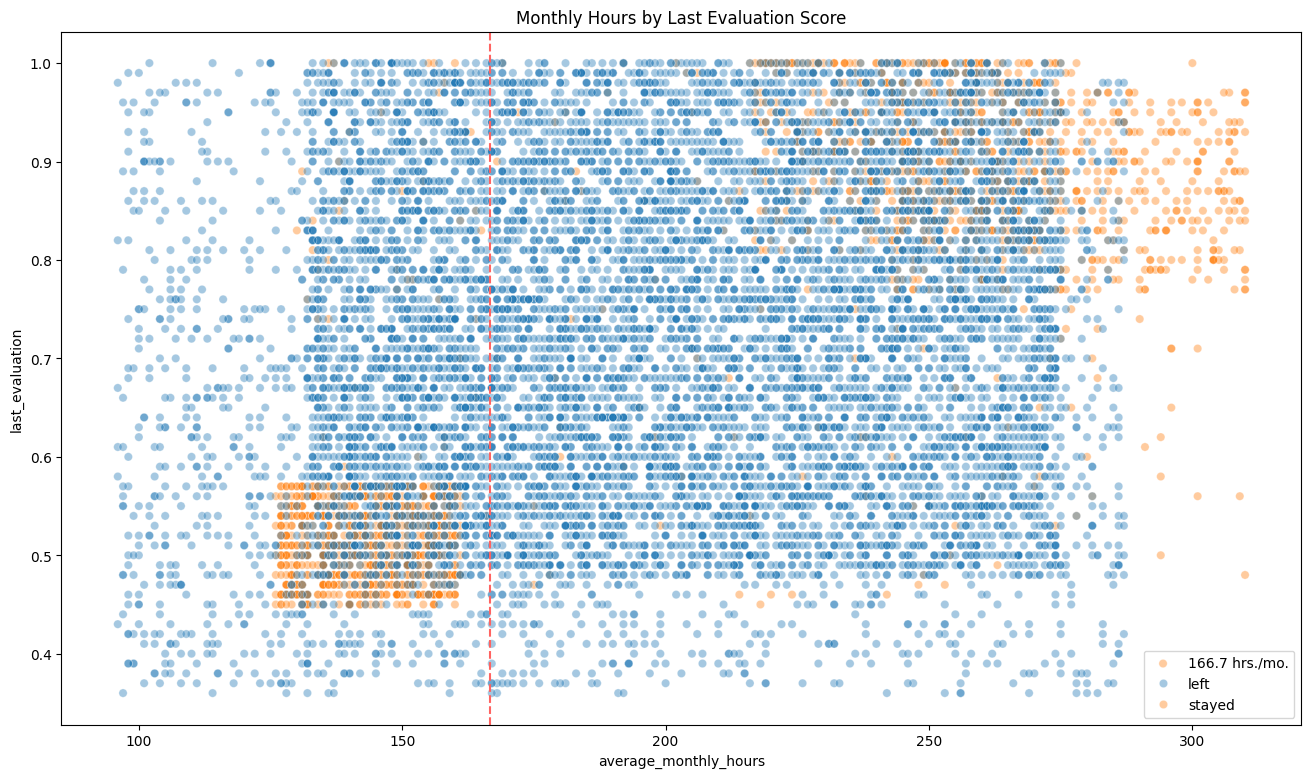

In [ ]:
# Create scatterplot of `average_monthly_hours` versus `last_evaluation`
plt.figure(figsize=(16, 9))
sns.scatterplot(data=df1, x='average_monthly_hours', y='last_evaluation', hue='left', alpha=0.4)
plt.axvline(x=166.7, color='#ff6361', label='166.7 hrs./mo.', ls='--')
plt.legend(labels=['166.7 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly Hours by Last Evaluation Score', fontsize='12')

Text(0.5, 1.0, 'Monthly Hours by Promotion in the Last 5 years')

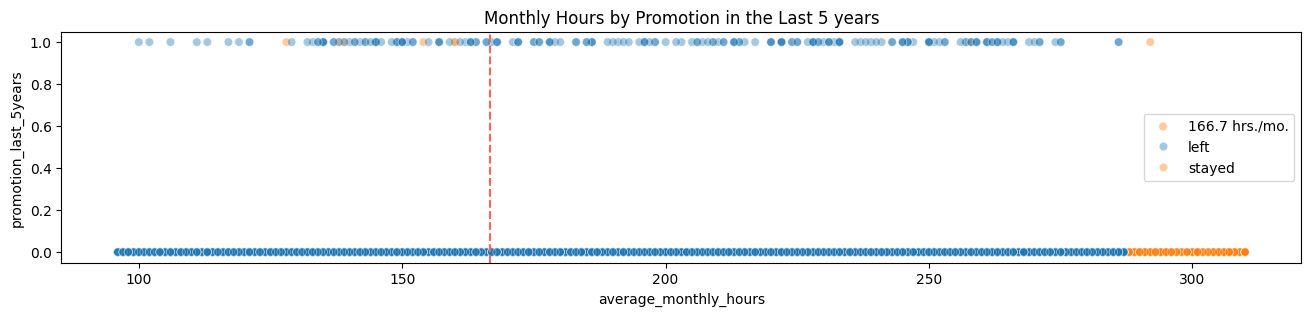

In [ ]:
# Create plot to examine relationship between `average_monthly_hours` and `promotion_last_5years`
plt.figure(figsize=(16, 3))
sns.scatterplot(data=df1, x='average_monthly_hours', y='promotion_last_5years', hue='left', alpha=0.4)
plt.axvline(x=166.7, color='#ff6361', ls='--')
plt.legend(labels=['166.7 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly Hours by Promotion in the Last 5 years', fontsize='12')

In [ ]:
df1["department"].value_counts()

,count
department,
sales,3239
technical,2244
support,1821
IT,976
RandD,694
product_mng,686
marketing,673
accounting,621
hr,601


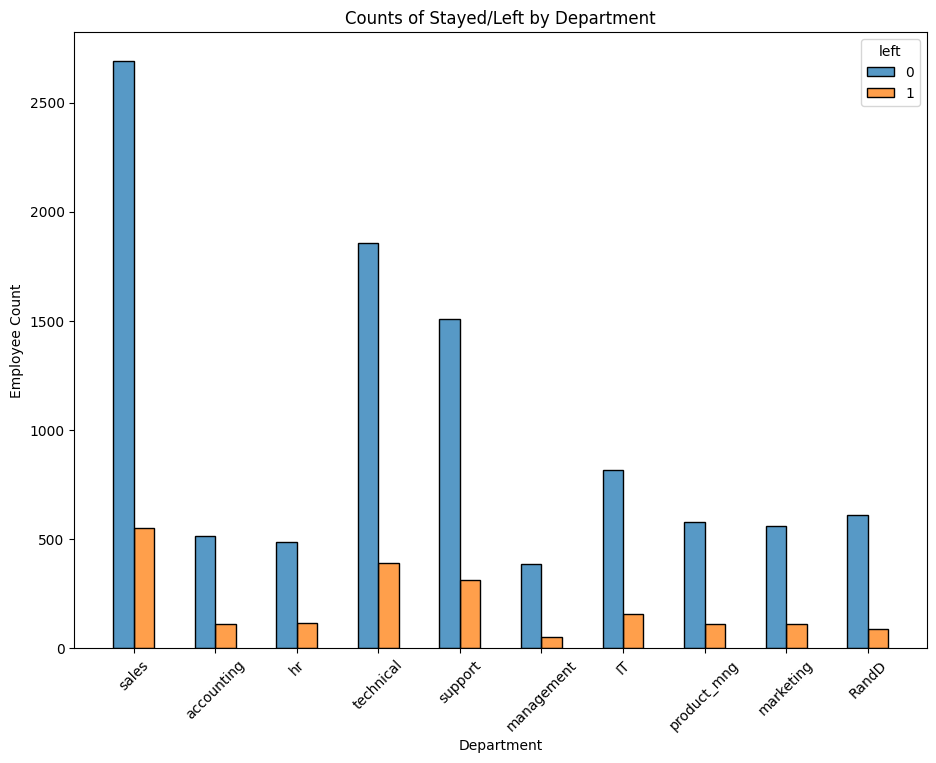

In [ ]:
# Create stacked histogram to compare department distribution of employees who left to that of employees who didn't
plt.figure(figsize=(11,8))
sns.histplot(data=df1, x='department', hue='left', discrete=1,
             hue_order=[0, 1], multiple='dodge', shrink=.5)
plt.xticks(rotation=45)
plt.title('Counts of Stayed/Left by Department', fontsize=12)
plt.ylabel('Employee Count')
plt.xlabel('Department')
plt.show()

Text(0.5, 1.0, 'Correlation Heatmap')

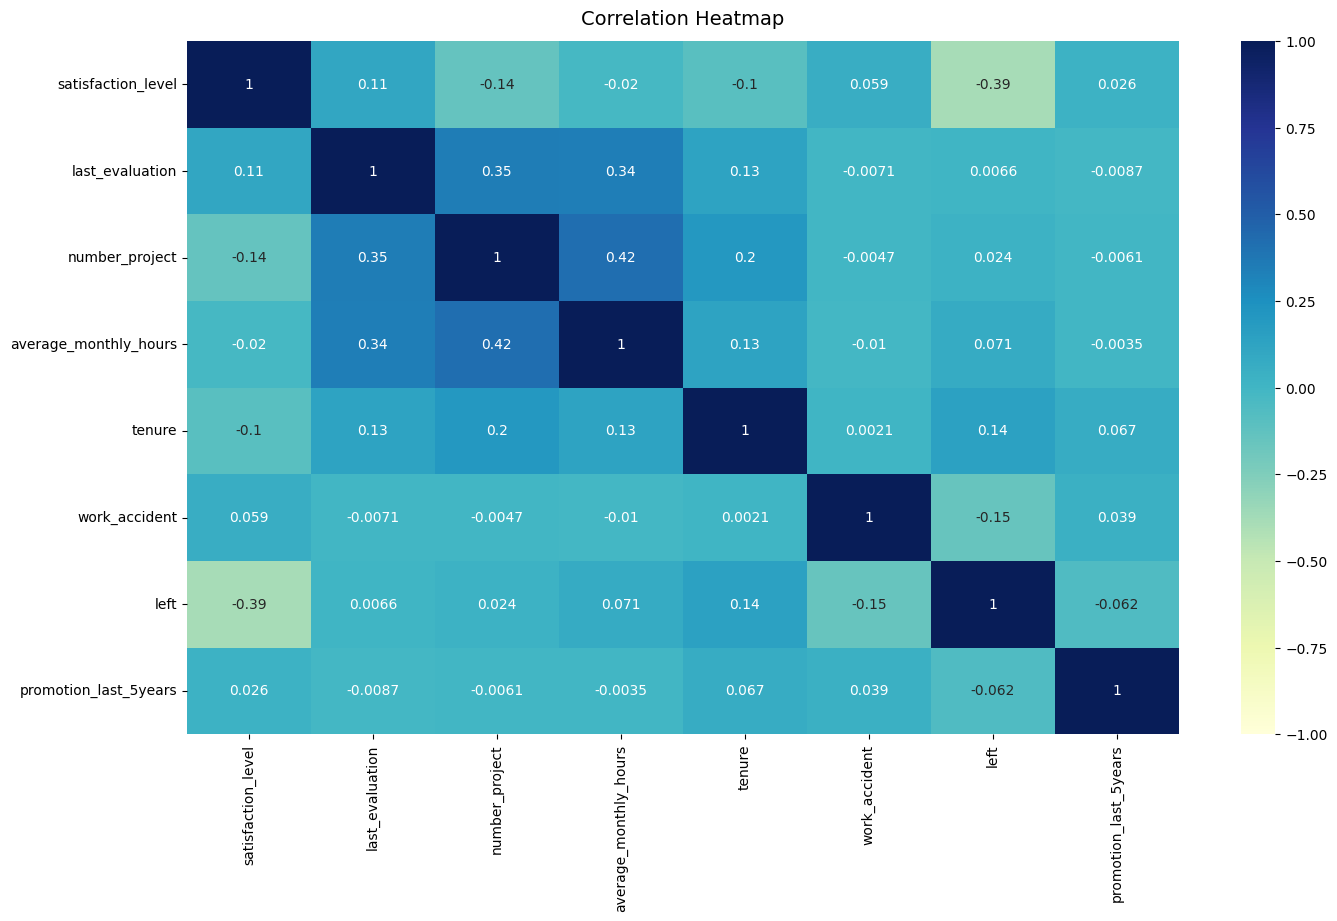

In [ ]:
# Plot a correlation heatmap
plt.figure(figsize=(16, 9))
heatmap = sns.heatmap(df0[['satisfaction_level', 'last_evaluation', 'number_project', 'average_monthly_hours', 'tenure', 'work_accident', 'left','promotion_last_5years']].corr(), vmin=-1, vmax=1, annot=True, cmap=sns.color_palette("YlGnBu", as_cmap=True))
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':14}, pad=12)

In [ ]:
df1['salary'].head()

,salary
0,low
1,medium
2,medium
3,low
4,low


In [ ]:
df_enc = df1.copy()

# Dummy encode the `department` column
df_enc = pd.get_dummies(df_enc, drop_first=False, columns=['department'])

# Encode the `salary` column as an ordinal numeric category
df_enc['salary'] = (df_enc['salary'].astype('category').cat.set_categories(['low', 'medium', 'high']).cat.codes)

df_enc.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False
1,0.80,0.86,5,262,6,0,1,0,1,False,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,1,0,1,False,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,1,0,0,False,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False


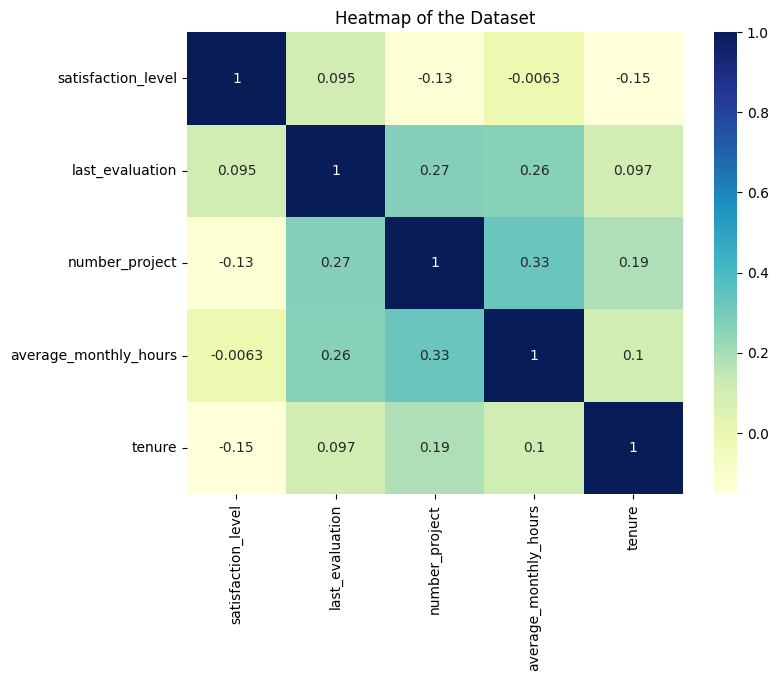

In [ ]:
# Create a heatmap to visualize how correlated variables are
plt.figure(figsize=(8, 6))
sns.heatmap(df_enc[['satisfaction_level', 'last_evaluation', 'number_project', 'average_monthly_hours', 'tenure']]
            .corr(), annot=True, cmap=sns.color_palette("YlGnBu", as_cmap=True))
plt.title('Heatmap of the Dataset')
plt.show()

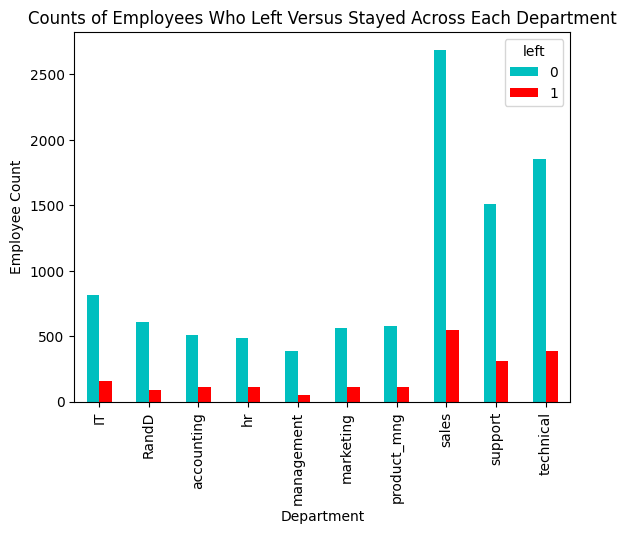

In [ ]:
# Create a stacked bart plot to visualize number of employees across department, comparing those who left with those who didn't
# In the legend, 0 (purple color) represents employees who did not leave, 1 (red color) represents employees who left
pd.crosstab(df1['department'], df1['left']).plot(kind ='bar',color='cr')
plt.title('Counts of Employees Who Left Versus Stayed Across Each Department', fontsize=12)
plt.ylabel('Employee Count')
plt.xlabel('Department')
plt.show()

In [ ]:
# Select rows without outliers in `tenure` and save resulting dataframe in a new variable
df_logreg = df_enc[(df_enc['tenure'] >= lower_limit) & (df_enc['tenure'] <= upper_limit)]

df_logreg.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,1,0,1,False,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,1,0,0,False,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False
5,0.41,0.50,2,153,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False


In [ ]:
# Isolate the outcome variable
y = df_logreg['left']

# Select the features you want to use in your model
X = df_logreg.drop('left', axis=1)

In [ ]:
# Split the data into training set and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

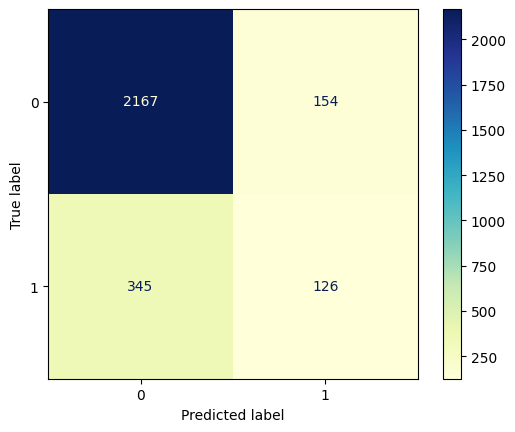

In [ ]:
# Construct a logistic regression model and fit it to the training dataset
log_clf = LogisticRegression(random_state=42, max_iter=500).fit(X_train, y_train)

# Use the logistic regression model to get predictions on the test set
y_pred = log_clf.predict(X_test)

# Compute values for confusion matrix
log_cm = confusion_matrix(y_test, y_pred, labels=log_clf.classes_)

# Create display of confusion matrix
log_disp = ConfusionMatrixDisplay(confusion_matrix=log_cm,
                                  display_labels=log_clf.classes_)

# Plot confusion matrix
log_disp.plot(values_format='', cmap=plt.cm.YlGnBu)

plt.show()

In [ ]:
# Create classification report for logistic regression model
target_names = ['Predicted would not leave', 'Predicted would leave']
print(classification_report(y_test, y_pred, target_names=target_names))

                           precision    recall  f1-score   support

Predicted would not leave       0.86      0.93      0.90      2321
    Predicted would leave       0.45      0.27      0.34       471

                 accuracy                           0.82      2792
                macro avg       0.66      0.60      0.62      2792
             weighted avg       0.79      0.82      0.80      2792



In [ ]:
# Isolate the outcome variable
y = df_logreg['left']

# Select the features you want to use in your model
X = df_logreg.drop('left', axis=1)

In [ ]:
# Split the data into training set and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

In [ ]:
# Define a path to the folder where you want to save the model
path = '/content/'

In [ ]:
def write_pickle(path, model_object, save_as:str):
    '''
    In:
        path:         path of folder where you want to save the pickle
        model_object: a model you want to pickle
        save_as:      filename for how you want to save the model

    Out: A call to pickle the model in the folder indicated
    '''

    with open(path + save_as + '.pickle', 'wb') as to_write:
        pickle.dump(model_object, to_write)

In [ ]:
def read_pickle(path, saved_model_name:str):
    '''
    In:
        path:             path to folder where you want to read from
        saved_model_name: filename of pickled model you want to read in

    Out:
        model: the pickled model
    '''
    with open(path + saved_model_name + '.pickle', 'rb') as to_read:
        model = pickle.load(to_read)

    return model

In [ ]:
# Instantiate model
tree = DecisionTreeClassifier(random_state=0)

# Assign a dictionary of hyperparameters to search over
cv_params = {'max_depth':[4, 6, 8, None],
             'min_samples_leaf': [2, 5, 1],
             'min_samples_split': [2, 4, 6]
             }

# Assign a dictionary of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Instantiate GridSearch
tree1 = GridSearchCV(tree, cv_params, scoring=scoring, cv=4, refit='f1')

In [ ]:
%%time
# Fit the decision tree model to the training data.
tree1.fit(X_train, y_train) #Wall time: ~5s

CPU times: user 5.73 s, sys: 27.8 ms, total: 5.76 s
Wall time: 5.91 s


GridSearchCV(cv=4, estimator=DecisionTreeClassifier(random_state=0),
             param_grid={'max_depth': [4, 6, 8, None],
                         'min_samples_leaf': [2, 5, 1],
                         'min_samples_split': [2, 4, 6]},
             refit='f1',
             scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])

In [ ]:
# Write pickle
write_pickle(path, tree1, 'hr_tree1')

In [ ]:
# Read pickle
tree1 = read_pickle(path, 'hr_tree1')

In [ ]:
# Check best parameters
tree1.best_params_

{'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 4}

In [ ]:
# Check best F1 score on CV
tree1.best_score_

0.9433189253326553

In [ ]:
def make_results(model_name:str, model_object, metric:str):
    '''
    Arguments:
        model_name (string): what you want the model to be called in the output table
        model_object: a fit GridSearchCV object
        metric (string): precision, recall, f1, accuracy, or auc

    Returns a pandas df with the F1, recall, precision, accuracy, and auc scores
    for the model with the best mean 'metric' score across all validation folds.
    '''

    # Create dictionary that maps input metric to actual metric name in GridSearchCV
    metric_dict = {'auc': 'mean_test_roc_auc',
                   'precision': 'mean_test_precision',
                   'recall': 'mean_test_recall',
                   'f1': 'mean_test_f1',
                   'accuracy': 'mean_test_accuracy'
                  }

    # Get all the results from the CV and put them in a df
    cv_results = pd.DataFrame(model_object.cv_results_)

    # Isolate the row of the df with the max(metric) score
    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]

    # Extract Accuracy, precision, recall, and f1 score from that row
    auc = best_estimator_results.mean_test_roc_auc
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy

    # Create table of results
    table = pd.DataFrame()
    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'F1': [f1],
                          'accuracy': [accuracy],
                          'auc': [auc]
                        })

    return table

In [ ]:
# Get all CV scores
tree_cv_results = []
tree_cv_results = make_results('Decision Tree CV 1', tree1, 'f1')
tree_cv_results

,model,precision,recall,F1,accuracy,auc
0,Decision Tree CV 1,0.972884,0.915674,0.943319,0.981493,0.966464


In [ ]:
# Instantiate model
rf = RandomForestClassifier(random_state=0)

# Assign a dictionary of hyperparameters to search over
cv_params = {'max_depth': [3,5, None],
             'max_features': [1.0],
             'max_samples': [0.7, 1.0],
             'min_samples_leaf': [1,2,3],
             'min_samples_split': [2,3,4],
             'n_estimators': [300, 500],
             }

# Assign a dictionary of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Instantiate GridSearch
rf1 = GridSearchCV(rf, cv_params, scoring=scoring, cv=4, refit='f1')

In [ ]:
%%time
# Fit the random forest model to the training data.
#rf1.fit(X_train, y_train) #Wall time: ~29min

CPU times: user 3 µs, sys: 0 ns, total: 3 µs
Wall time: 7.87 µs


In [ ]:
# Write pickle
#write_pickle(path, rf1, 'hr_rf1')

In [ ]:
#!pip install -U scikit-learn

In [ ]:
#pip install scikit-learn==1.2.2

In [ ]:
# Read pickle
rf1 = read_pickle(path, 'hr_rf1')

In [ ]:
# Check best params
rf1.best_params_

{'max_depth': None,
 'max_features': 1.0,
 'max_samples': 0.7,
 'min_samples_leaf': 1,
 'min_samples_split': 4,
 'n_estimators': 300}

In [ ]:
# Check best F1 score on CV
rf1.best_score_

0.9508921491494166

In [ ]:
# Get all CV scores using the make_results() function defined earlier.
rf1_cv_results = make_results('Random Forest CV 1', rf1, 'f1')
tree_cv_results = pd.concat([tree_cv_results, rf1_cv_results], axis=0)
tree_cv_results = tree_cv_results.reset_index(drop=True)
tree_cv_results

,model,precision,recall,F1,accuracy,auc
0,Decision Tree CV 1,0.972884,0.915674,0.943319,0.981493,0.966464
1,Random Forest CV 1,0.990775,0.914256,0.950892,0.984120,0.974648


In [ ]:
# 1. Instantiate the XGBoost classifier
xgb = XGBClassifier(objective='binary:logistic', random_state=0)

# 2. Create a dictionary of hyperparameters to tune
cv_params = {'learning_rate': [0.1,0.2,0.3],
             'max_depth': [1,3,5,7],
             'min_child_weight': [0.2,0.5,0.9,1,2,5],
             'n_estimators': [30,50,100,200]
             }

# 3. Define a dictionary of scoring metrics to capture
scoring = {'accuracy', 'precision', 'recall', 'f1', 'roc_auc'}

# 4. Instantiate the GridSearchCV object
xgb1 = GridSearchCV(xgb, cv_params, scoring=scoring, cv=4, refit='f1')

In [ ]:
%%time
# Fit the XGBoost model to the training data.
#xgb1.fit(X_train, y_train) #Wall time: ~5min

CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 7.87 µs


In [ ]:
# Write pickle
#write_pickle(path, xgb1, 'hr_xgb1')

In [ ]:
# Read pickle
xgb1 = read_pickle(path, 'hr_xgb1')

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [12:46:54] WARNING: /workspace/src/collective/../data/../common/error_msg.h:80: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  warnings.warn(smsg, UserWarning)


In [ ]:
# Examine best parameters
xgb1.best_params_

{'learning_rate': 0.1,
 'max_depth': 7,
 'min_child_weight': 0.2,
 'n_estimators': 100}

In [ ]:
# Examine best score
xgb1.best_score_

0.9503805615950303

In [ ]:
# Call 'make_results()' on the GridSearch object
xgb1_cv_results = make_results('XGB CV 1', xgb1, 'f1')
tree_cv_results = pd.concat([tree_cv_results, xgb1_cv_results], axis=0)
tree_cv_results = tree_cv_results.reset_index(drop=True)
tree_cv_results

,model,precision,recall,F1,accuracy,auc
0,Decision Tree CV 1,0.972884,0.915674,0.943319,0.981493,0.966464
1,Random Forest CV 1,0.990775,0.914256,0.950892,0.984120,0.974648
2,XGB CV 1,0.985528,0.917799,0.950381,0.983881,0.983306


In [ ]:
def get_scores(model_name:str, model, X_test_data, y_test_data):
    '''
    Generate a table of test scores.

    In:
        model_name (string):  How you want your model to be named in the output table
        model:                A fit GridSearchCV object
        X_test_data:          numpy array of X_test data
        y_test_data:          numpy array of y_test data

    Out: pandas df of precision, recall, f1, accuracy, and AUC scores for your model
    '''

    preds = model.best_estimator_.predict(X_test_data)

    auc = roc_auc_score(y_test_data, preds)
    accuracy = accuracy_score(y_test_data, preds)
    precision = precision_score(y_test_data, preds)
    recall = recall_score(y_test_data, preds)
    f1 = f1_score(y_test_data, preds)

    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'f1': [f1],
                          'accuracy': [accuracy],
                          'AUC': [auc]
                         })

    return table

In [ ]:
# Get predictions on test data
rf1_test_scores = get_scores('Random Forest CV 1', rf1, X_test, y_test)
rf1_test_scores

,model,precision,recall,f1,accuracy,AUC
0,Random Forest CV 1,0.993213,0.932059,0.961665,0.987464,0.965383


Round 2

In [ ]:
# Drop `satisfaction_level` and save resulting dataframe in new variable
df2 = df_enc.drop('satisfaction_level', axis=1)

df2.head()

,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.53,2,157,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False
1,0.86,5,262,6,0,1,0,1,False,False,False,False,False,False,False,True,False,False
2,0.88,7,272,4,0,1,0,1,False,False,False,False,False,False,False,True,False,False
3,0.87,5,223,5,0,1,0,0,False,False,False,False,False,False,False,True,False,False
4,0.52,2,159,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False


In [ ]:
# Create `overworked` column. For now, it's identical to average monthly hours.
df2['overworked'] = df2['average_monthly_hours']

# Inspect max, min and mean average_monthly_hours values
print('Max hours:', df2['overworked'].max())
print('Min hours:', df2['overworked'].min())
print('Mean hours:', df2['overworked'].mean())

Max hours: 310
Min hours: 96
Mean hours: 200.4735218080227


In [ ]:
# Define `overworked` as working > 200 hrs/week
df2['overworked'] = (df2['overworked'] > 200).astype(int)

df2['overworked'].head()

,overworked
0,0
1,1
2,1
3,1
4,0


In [ ]:
#X_train=X_train.drop(X_train.columns[6:16], axis=1)


In [ ]:
# Drop the `average_monthly_hours` column
df2 = df2.drop('average_monthly_hours', axis=1)

df2.head()

,last_evaluation,number_project,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,overworked
0,0.53,2,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False,0
1,0.86,5,6,0,1,0,1,False,False,False,False,False,False,False,True,False,False,1
2,0.88,7,4,0,1,0,1,False,False,False,False,False,False,False,True,False,False,1
3,0.87,5,5,0,1,0,0,False,False,False,False,False,False,False,True,False,False,1
4,0.52,2,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False,0


In [ ]:
# Isolate the outcome variable
y = df2['left']

# Select the features
X = df2.drop('left', axis=1)

# Create test data and stratify based on y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)

In [ ]:
# Instantiate model
tree = DecisionTreeClassifier(random_state=0)

# Assign a dictionary of hyperparameters to search over
cv_params = {'max_depth':[4, 6, 8, None],
             'min_samples_leaf': [2, 5, 1],
             'min_samples_split': [2, 4, 6]
             }

# Assign a dictionary of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Instantiate GridSearch
tree2 = GridSearchCV(tree, cv_params, scoring=scoring, cv=4, refit='f1')

In [ ]:
%%time
# Fit the Decision Tree model to the training data.
tree2.fit(X_train, y_train) #Wall time: ~20s

CPU times: user 4.07 s, sys: 29.6 ms, total: 4.1 s
Wall time: 4.14 s


GridSearchCV(cv=4, estimator=DecisionTreeClassifier(random_state=0),
             param_grid={'max_depth': [4, 6, 8, None],
                         'min_samples_leaf': [2, 5, 1],
                         'min_samples_split': [2, 4, 6]},
             refit='f1',
             scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])

In [ ]:
# Write pickle
write_pickle(path, tree2, 'hr_tree2')

In [ ]:
# Read pickle
tree2 = read_pickle(path, 'hr_tree2')

In [ ]:
# Check best params
tree2.best_params_

{'max_depth': 8, 'min_samples_leaf': 5, 'min_samples_split': 2}

In [ ]:
# Check best F1 score on CV
tree2.best_score_

0.896450396815005

In [ ]:
# Get all CV scores
tree2_cv_results = make_results('Decision Tree CV 2', tree2, 'f1')
tree_cv_results = pd.concat([tree_cv_results, tree2_cv_results], axis=0)
tree_cv_results = tree_cv_results.reset_index(drop=True)
tree_cv_results

,model,precision,recall,F1,accuracy,auc
0,Decision Tree CV 1,0.972884,0.915674,0.943319,0.981493,0.966464
1,Random Forest CV 1,0.990775,0.914256,0.950892,0.984120,0.974648
2,XGB CV 1,0.985528,0.917799,0.950381,0.983881,0.983306
3,Decision Tree CV 2,0.900241,0.892831,0.896450,0.965751,0.956486


In [ ]:
# Instantiate model
rf = RandomForestClassifier(random_state=0)

# Assign a dictionary of hyperparameters to search over
cv_params = {'max_depth': [3,5, None],
             'max_features': [1.0],
             'max_samples': [0.7, 1.0],
             'min_samples_leaf': [1,2,3],
             'min_samples_split': [2,3,4],
             'n_estimators': [300, 500],
             }

# Assign a dictionary of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Instantiate GridSearch
rf2 = GridSearchCV(rf, cv_params, scoring=scoring, cv=4, refit='f1')

In [ ]:
%%time
# Fit the Random Forest model to the training data.
#rf2.fit(X_train, y_train) #Wall time ~23min

CPU times: user 4 µs, sys: 1 µs, total: 5 µs
Wall time: 7.87 µs


In [ ]:
# Write pickle
#write_pickle(path, rf2, 'hr_rf2')

In [ ]:
# Read in pickle
rf2 = read_pickle(path, 'hr_rf2')

In [ ]:
# Check best params
rf2.best_params_

{'max_depth': None,
 'max_features': 1.0,
 'max_samples': 0.7,
 'min_samples_leaf': 3,
 'min_samples_split': 2,
 'n_estimators': 500}

In [ ]:
# Check best F1 score on CV
rf2.best_score_

0.9045143275295622

In [ ]:
rf2_cv_results = make_results('Random Forest CV 2', rf2, 'f1')
tree_cv_results = pd.concat([tree_cv_results, rf2_cv_results], axis=0)
tree_cv_results = tree_cv_results.reset_index(drop=True)
tree_cv_results

,model,precision,recall,F1,accuracy,auc
0,Decision Tree CV 1,0.972884,0.915674,0.943319,0.981493,0.966464
1,Random Forest CV 1,0.990775,0.914256,0.950892,0.984120,0.974648
2,XGB CV 1,0.985528,0.917799,0.950381,0.983881,0.983306
3,Decision Tree CV 2,0.900241,0.892831,0.896450,0.965751,0.956486
4,Random Forest CV 2,0.917981,0.891494,0.904514,0.968754,0.963271


In [ ]:
# 1. Instantiate the XGBoost classifier
xgb = XGBClassifier(objective='binary:logistic', random_state=0)

# 2. Create a dictionary of hyperparameters to tune
cv_params = {'learning_rate': [0.1,0.2,0.3],
             'max_depth': [1,3,5,7],
             'min_child_weight': [0.2,0.5,0.9,1,2,5],
             'n_estimators': [30,50,100,200]
             }

# 3. Define a dictionary of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# 4. Instantiate the GridSearchCV object
xgb2 = GridSearchCV(xgb, cv_params, scoring=scoring, cv=4, refit='f1')

In [ ]:
%%time
# Fit the XGBoost model to the training data.
#xgb2.fit(X_train, y_train) #Wall time: ~5min

CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 8.58 µs


In [ ]:
# Write pickle
#write_pickle(path, xgb2, 'hr_xgb2')

In [ ]:
# Read in pickle
xgb2 = read_pickle(path, 'hr_xgb2')

In [ ]:
# Check best params
xgb2.best_params_

{'learning_rate': 0.2,
 'max_depth': 5,
 'min_child_weight': 0.2,
 'n_estimators': 30}

In [ ]:
# Check best F1 score on CV
xgb2.best_score_

0.9034042613043879

In [ ]:
xgb2_cv_results = make_results('XGB CV 2', xgb2, 'f1')
tree_cv_results = pd.concat([tree_cv_results, xgb2_cv_results], axis=0)
tree_cv_results = tree_cv_results.reset_index(drop=True)
tree_cv_results

,model,precision,recall,F1,accuracy,auc
0,Decision Tree CV 1,0.972884,0.915674,0.943319,0.981493,0.966464
1,Random Forest CV 1,0.990775,0.914256,0.950892,0.984120,0.974648
2,XGB CV 1,0.985528,0.917799,0.950381,0.983881,0.983306
3,Decision Tree CV 2,0.900241,0.892831,0.896450,0.965751,0.956486
4,Random Forest CV 2,0.917981,0.891494,0.904514,0.968754,0.963271
5,XGB CV 2,0.910917,0.896181,0.903404,0.968198,0.973581


In [ ]:
# Get predictions on test data
xgb2_test_scores = get_scores('XGB CV Test 2', xgb2, X_test, y_test)
xgb2_test_scores

,model,precision,recall,f1,accuracy,AUC
0,XGB CV Test 2,0.887795,0.905622,0.89662,0.96531,0.941411


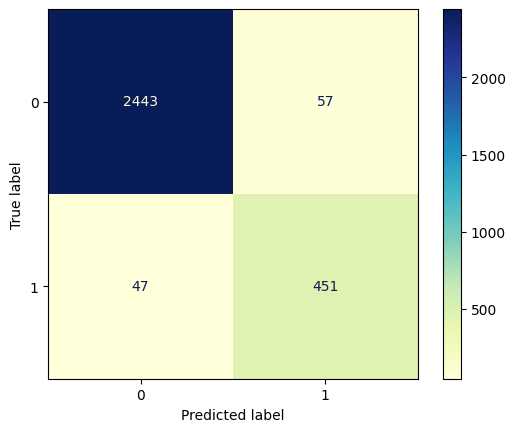

In [ ]:
# Generate array of values for confusion matrix
preds = xgb2.best_estimator_.predict(X_test)
cm = confusion_matrix(y_test, preds, labels=xgb2.classes_)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=xgb2.classes_)
disp.plot(values_format='', cmap=plt.cm.YlGnBu)
plt.show()

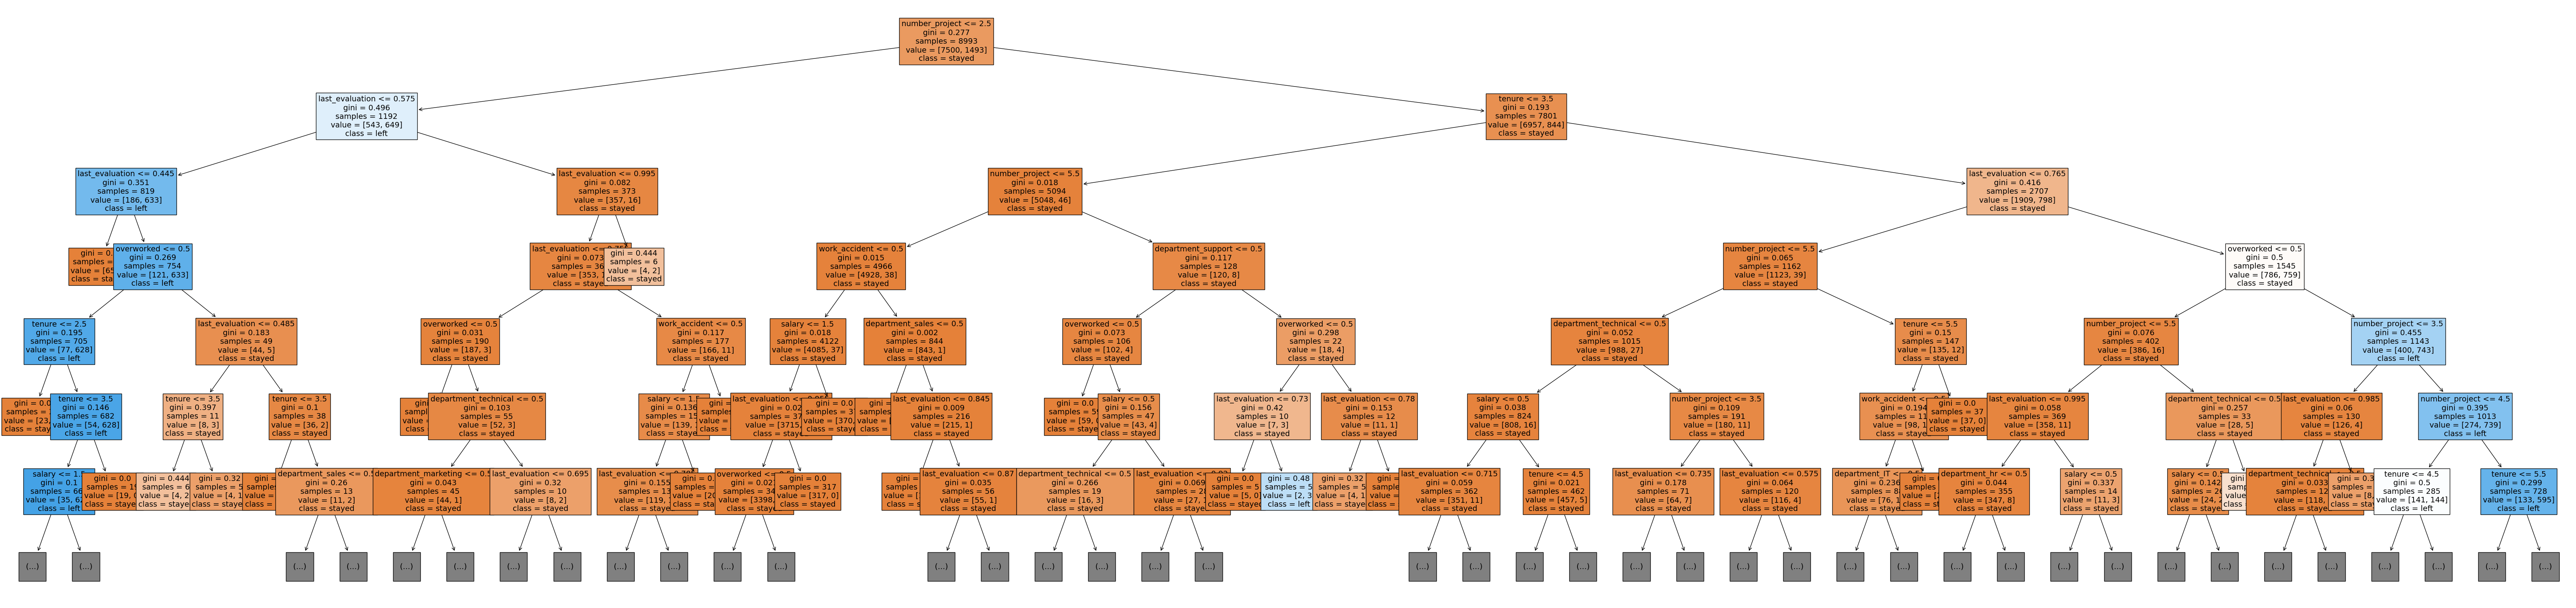

In [ ]:
# Plot the decision tree split
plt.figure(figsize=(85,20))
plot_tree(tree2.best_estimator_, max_depth=6, fontsize=14, feature_names=X.columns,
          class_names={0:'stayed', 1:'left'}, filled=True);
plt.show()

In [ ]:
# Sort features based on their importance using gini_importance
tree2_importances = pd.DataFrame(tree2.best_estimator_.feature_importances_,
                                 columns=['gini_importance'],
                                 index=X.columns
                                )
tree2_importances = tree2_importances.sort_values(by='gini_importance', ascending=False)

# Only extract the features with importances > 0
tree2_importances = tree2_importances[tree2_importances['gini_importance'] != 0]
tree2_importances

,gini_importance
last_evaluation,0.330981
number_project,0.290503
tenure,0.228743
overworked,0.143133
salary,0.002134
department_technical,0.001661
work_accident,0.001263
department_support,0.000559
department_sales,0.000507
department_IT,0.000255


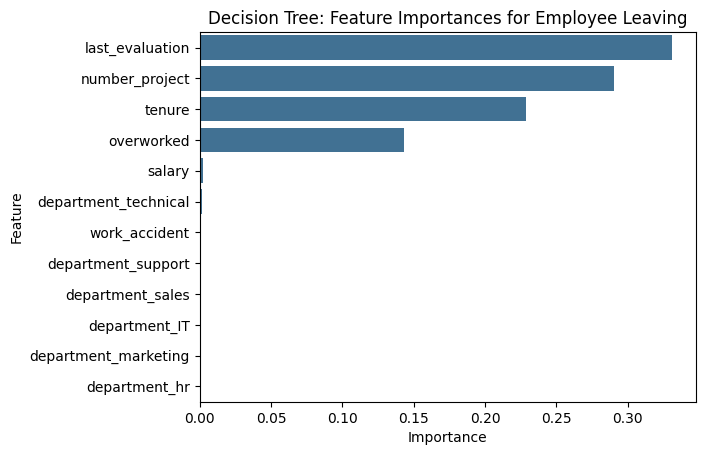

In [ ]:
# Create a barplot to visualize the decision tree feature importances
sns.barplot(data=tree2_importances, x="gini_importance", y=tree2_importances.index, orient='h', color='#3373a1')
plt.title("Decision Tree: Feature Importances for Employee Leaving", fontsize=12)
plt.ylabel("Feature")
plt.xlabel("Importance")
plt.show()

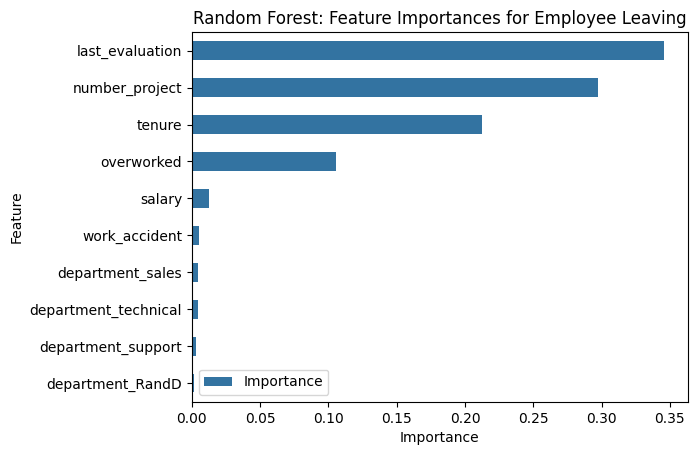

In [ ]:
# Get feature importances
feat_impt = rf2.best_estimator_.feature_importances_

# Get indices of top 10 features
ind = np.argpartition(rf2.best_estimator_.feature_importances_, -10)[-10:]

# Get column labels of top 10 features
feat = X.columns[ind]

# Filter `feat_impt` to consist of top 10 feature importances
feat_impt = feat_impt[ind]

y_df = pd.DataFrame({"Feature":feat,"Importance":feat_impt})
y_sort_df = y_df.sort_values("Importance")
fig = plt.figure()
ax1 = fig.add_subplot(111)

y_sort_df.plot(kind='barh',ax=ax1,x="Feature",y="Importance", color = "#3373a1")

ax1.set_title("Random Forest: Feature Importances for Employee Leaving", fontsize=12)
ax1.set_ylabel("Feature")
ax1.set_xlabel("Importance")

plt.show()

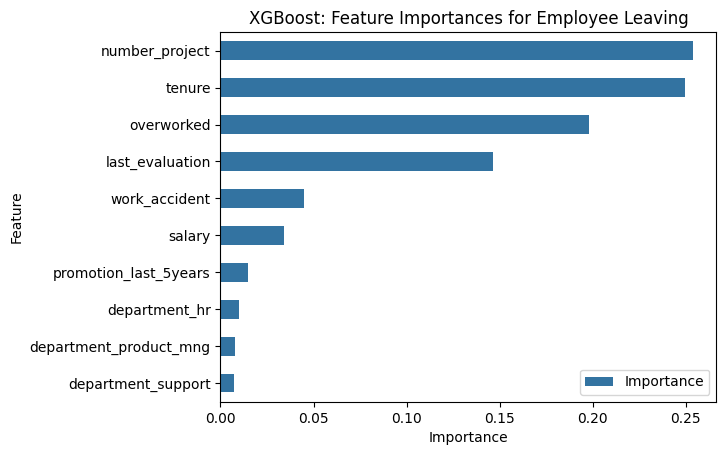

In [ ]:
# Get feature importances
feat_impt = xgb2.best_estimator_.feature_importances_

# Get indices of top 10 features
ind = np.argpartition(xgb2.best_estimator_.feature_importances_, -10)[-10:]

# Get column labels of top 10 features
feat = X.columns[ind]

# Filter `feat_impt` to consist of top 10 feature importances
feat_impt = feat_impt[ind]

y_df = pd.DataFrame({"Feature":feat,"Importance":feat_impt})
y_sort_df = y_df.sort_values("Importance")
fig = plt.figure()
ax1 = fig.add_subplot(111)

y_sort_df.plot(kind='barh',ax=ax1,x="Feature",y="Importance", color='#3373a1')

ax1.set_title("XGBoost: Feature Importances for Employee Leaving", fontsize=12)
ax1.set_ylabel("Feature")
ax1.set_xlabel("Importance")

plt.show()

In [ ]:
# Evaluate the model
best_model = xgb2.best_estimator_
print("\nBest Parameters:", xgb2.best_params_)
print("\nBest F1-Score:", xgb2.best_score_)

# Test set predictions
y_pred = best_model.predict(X_test)
print("\nClassification Report on Test Data:")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))


Best Parameters: {'learning_rate': 0.2, 'max_depth': 5, 'min_child_weight': 0.2, 'n_estimators': 30}

Best F1-Score: 0.9034042613043879

Classification Report on Test Data:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2500
           1       0.89      0.91      0.90       498

    accuracy                           0.97      2998
   macro avg       0.93      0.94      0.94      2998
weighted avg       0.97      0.97      0.97      2998

Accuracy: 0.9653102068045364


In [ ]:
write_pickle(path, xgb2, 'hr_xgb_final')

In [ ]:
import xgboost
print("XGBoost version:", xgboost.__version__)

XGBoost version: 2.1.3


In [ ]:
# Load the model
xgb_final = read_pickle(path, 'hr_xgb_final')
print("\nLoaded Model:", xgb_final)


Loaded Model: GridSearchCV(cv=4,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n

In [ ]:
# import pickle

# with open('/content/hr_xgb_final.pickle', 'rb') as file:
#     loaded_data = pickle.load(file)

# print(type(loaded_data))
# print(loaded_data.__dict__)  # Check attributes of the loaded object


In [ ]:
loaded_model = read_pickle(path, 'hr_xgb_final')
print("Model loaded successfully.")

Model loaded successfully.


In [ ]:
# Test the model on the test set
y_pred_test = loaded_model.predict(X_test)

# Evaluate the model
print("\nTest Set Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_test))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test))


Test Set Evaluation:
Accuracy: 0.9653102068045364

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2500
           1       0.89      0.91      0.90       498

    accuracy                           0.97      2998
   macro avg       0.93      0.94      0.94      2998
weighted avg       0.97      0.97      0.97      2998



In [ ]:
# Predict for a new employee
new_employee = np.array([[0.5, 8, 200, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1]])  # Replace strings with numbers
  # Fill missing features with 0
new_employee_reshaped = new_employee.reshape(1, -1)
  # Example input
# Features: [satisfaction_level,number_project, hours_worked ,work_accident , promotion_last_5years , salary
            #department_IT,department_RandD ,department_accounting ,department_hr ,department_management,
            #department_marketing ,department_product_mng ,department_sales ,department_support ,
            #department_technicalsalary ,overworked ]

# Ensure the input has the correct shape
new_employee_reshaped = new_employee.reshape(1, -1)

# Predict
new_prediction = loaded_model.predict(new_employee_reshaped)

# Interpret the prediction
print("\nPrediction for New Employee:")
print("Employee Stays" if new_prediction[0] == 0 else "Employee Leaves")


Prediction for New Employee:
Employee Stays
